# DNSSEC RFC adoption: OpenINTEL forward DNS vs RIPE reverse delegations

Two independent measurement corpora, cross-referenced.

| | **OpenINTEL** (forward DNS) | **RIPE** (reverse delegations) |
|---|---|---|
| What it measures | what zones *publish* for `.gov`, `.nu`, `.se` | every delegation in `in-addr.arpa` + `ip6.arpa`, all five RIRs |
| Window | 2018-01 → 2026-04 | 2009-04 → 2026-08 |
| Volume | 2,755,488,262 records | 1,875,584 DS records over 1.33M delegations/day |
| Population | registrants (people who bought a domain) | network operators (people allocated an IP block) |
| Denominator | share of **records** | share of **delegations** (zones) |

They share no infrastructure, no operator population and no collection method. So
where they *agree*, the agreement is evidence. Where they *disagree*, the
disagreement is usually telling us something about the measurement rather than
about DNSSEC — and this notebook is mostly about telling those two cases apart.

**Read this first if you read nothing else:** section 3 is a real agreement worth
reporting, section 4 is a 10x apparent disagreement that turns out to be an
artefact of what each side counts, section 5 is what the reverse corpus can do
that the forward one structurally cannot, and sections 6-7 are the structure the
pooled numbers hide — including the largest single effect in the data, which is
that IPv6 delegations are ten times more likely to be signed than IPv4 ones.

## 1. Setup and provenance

Everything below is derived from checkpoints committed in this repository, so the
notebook re-runs from a fresh clone. No network access, no hidden state.

In [1]:
import collections
import datetime
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Palette: the validated light-mode instance used throughout this project.
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, CRITICAL = "#e1e0d9", "#c3c2b7", "#d03b3b"
FWD, REV, THIRD = "#2a78d6", "#eb6834", "#1baf7a"      # forward, reverse, third series
RAMP = ["#86b6ef", "#2a78d6", "#104281"]

plt.rcParams.update({
    "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "text.color": INK,
    "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "figure.dpi": 110, "savefig.dpi": 200,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "axes.titlesize": 13,
})

# Resolve the repository root by walking up, so the notebook works whether it is
# opened from notebooks/, from the repo root, or from a Jupyter server rooted
# somewhere else entirely.
ROOT = Path.cwd()
while not (ROOT / "data" / "rfc_checklists").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError("run this notebook from inside the rfc_adoption repository")
    ROOT = ROOT.parent
print("repository root:", ROOT)

FIGDIR = ROOT / "reporting" / "charts" / "crossref"
FIGDIR.mkdir(parents=True, exist_ok=True)


def style(ax, axis="y"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.tick_params(length=0)


def pct(ax):
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}%"))


def years(ax, values, step=2):
    '''Integer year ticks; a numeric axis otherwise renders 2012.5, which is not a year.'''
    lo, hi = min(values), max(values)
    ax.set_xticks([y for y in range(lo, hi + 1) if (y - lo) % step == 0 or y == hi])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v)}"))


def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight", pad_inches=0.28)
    return FIGDIR / f"{name}.png"

repository root: E:\Documents\University\year2\DNSSEC\rfc_adoption


In [2]:
DATA = json.loads((ROOT / "out/analysis/crossref_data.json").read_text(encoding="utf-8"))
SUMMARY_DIR = ROOT / "out/reverse/corpus/reverse/_summary"

def frame(side):
    '''Per (source, year, rfc) match counts and the scanned denominator.'''
    scanned = collections.defaultdict(int)
    for key, value in DATA[side]["scanned"].items():
        source, year = key.split("|")
        scanned[(source, year)] += value
    rows = []
    for key, value in DATA[side]["per"].items():
        source, year, rfc = key.split("|")
        rows.append({"source": source, "year": year, "rfc": rfc, "matches": value,
                     "scanned": scanned[(source, year)]})
    df = pd.DataFrame(rows)
    df["share"] = df.matches / df.scanned * 100
    return df, pd.Series(scanned).rename_axis(["source", "year"]).rename("scanned")

fwd, fwd_scan = frame("openintel")
rev, rev_scan = frame("reverse")

def by_year(df, rfc):
    '''Corpus-wide share for one RFC, pooled across sources.'''
    years = sorted(df.year.unique())
    tot = df.groupby("year").apply(
        lambda g: g.drop_duplicates("source").scanned.sum(), include_groups=False)
    hit = df[df.rfc == rfc].groupby("year").matches.sum()
    # Reindex over every scanned year: a year with no match is a measured zero,
    # not a missing point, and dropping it makes a series look like it starts
    # when adoption starts.
    return (hit.reindex(years, fill_value=0) / tot.reindex(years) * 100).sort_index()

print(f"forward : {fwd_scan.sum():>15,} records, "
      f"{fwd.source.nunique()} zones, {fwd.year.min()}-{fwd.year.max()}")
print(f"reverse : {rev_scan.sum():>15,} DS records, "
      f"{rev.source.nunique()} RIRs,  {rev.year.min()}-{rev.year.max()}")

forward :   2,755,488,262 records, 3 zones, 2018-2026
reverse :       1,875,584 DS records, 5 RIRs,  2009-2026


## 2. Are these two things even comparable?

Three checks before any chart, because the answer to each one bounds what the
comparison is allowed to claim.

**(a) Same indicator definitions?** The forward corpus was scanned under checklist
`0.1.0` and the reverse one under `0.2.0`. That difference is only additive — the
eight RFCs present in both are byte-identical in their indicators, specificity and
publication date, verified below. So per-RFC counts *are* comparable; only the 22
RFCs added in `0.2.0` exist on one side alone.

**(b) Same denominator?** No, and this is the important one. Both sides report
"share of scanned rows", but a scanned row means something different:

- **forward**: any DNSSEC record — `DNSKEY`, `RRSIG`, `DS`, `NSEC`, `NSEC3`, `CDS`, `CDNSKEY`
- **reverse**: a `DS` record, and nothing else — a delegation zone contains no keys or signatures

An indicator scoped to DS records therefore has a *structurally* larger share on
the reverse side. Section 4 is what that looks like when you forget it.

**(c) Same population?** No. Forward DNS is registrants; reverse DNS is network
operators, allocated in blocks, far more concentrated. Neither speaks for "the
DNS", and agreement between them is meaningful precisely because they are
different.

In [3]:
import subprocess

new = json.loads((ROOT / "data/rfc_checklists/dnssec_rfc_checklists.json").read_text(encoding="utf-8"))
old = json.loads(subprocess.run(
    ["git", "show", "9ca61aa:data/rfc_checklists/dnssec_rfc_checklists.json"],
    capture_output=True, text=True, cwd=ROOT).stdout)

o = {r["rfc_id"]: r for r in old["rfcs"]}
n = {r["rfc_id"]: r for r in new["rfcs"]}
identical = [k for k in o if (o[k]["indicators"], o[k]["specificity"], o[k]["publication_date"])
             == (n[k]["indicators"], n[k]["specificity"], n[k]["publication_date"])]

print(f"checklist {old['checklist_version']} -> {new['checklist_version']}")
print(f"RFCs in both: {len(o)}   definitions unchanged: {len(identical)}/{len(o)}")
print(f"added in 0.2.0: {len(n) - len(o)}")
assert len(identical) == len(o), "an RFC changed definition; counts are NOT comparable"
print("\nOK - the shared RFCs are directly comparable across the two corpora.")
SHARED = sorted(identical, key=lambda r: int(r.split()[1]))
print("shared:", ", ".join(SHARED))

checklist 0.1.0 -> 0.2.0
RFCs in both: 8   definitions unchanged: 8/8
added in 0.2.0: 22

OK - the shared RFCs are directly comparable across the two corpora.
shared: RFC 4033, RFC 4509, RFC 5155, RFC 6605, RFC 7344, RFC 8078, RFC 8080, RFC 8624


## 3. Where they agree: ECDSA

RFC 6605 (ECDSA P-256/P-384, algorithms 13 and 14) is matched on the algorithm
number alone, independent of record type. A signed zone publishes its `DNSKEY`,
its `RRSIG`s and its parent `DS` all under the same algorithm, so the *algorithm
mix* is comparable across the two corpora even though the record populations are
not.

The two curves start 15 points apart, cross, and land within 1.7 points of each
other in 2026 — measured on different infrastructure, over different operators,
by different methods.

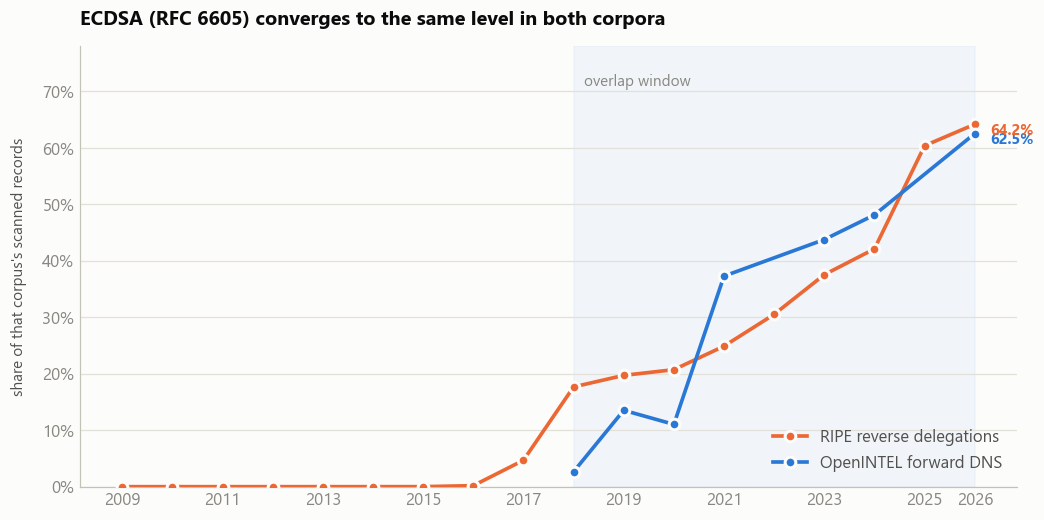

2026 gap between the two corpora: 1.65 percentage points
reverse leads early (2018: 17.7% vs 2.6%),
forward catches up and both land near 63%.


In [4]:
e_fwd, e_rev = by_year(fwd, "RFC 6605"), by_year(rev, "RFC 6605")
overlap = sorted(set(e_fwd.index) & set(e_rev.index))

fig, ax = plt.subplots(figsize=(11, 5.2))
full = sorted(e_rev.index)
ax.plot([int(y) for y in full], e_rev[full].values, color=REV, lw=2.4, marker="o",
        ms=7, mfc=REV, mec=SURFACE, mew=2, label="RIPE reverse delegations", zorder=3)
ax.plot([int(y) for y in sorted(e_fwd.index)], e_fwd[sorted(e_fwd.index)].values,
        color=FWD, lw=2.4, marker="o", ms=7, mfc=FWD, mec=SURFACE, mew=2,
        label="OpenINTEL forward DNS", zorder=4)

ax.axvspan(int(overlap[0]), int(overlap[-1]), color=FWD, alpha=0.05, zorder=0)
ax.annotate("overlap window", (int(overlap[0]) + 0.2, 71), color=MUTED, fontsize=10)

gap_end = abs(e_fwd[overlap[-1]] - e_rev[overlap[-1]])
for value, colour in ((e_fwd[overlap[-1]], FWD), (e_rev[overlap[-1]], REV)):
    ax.annotate(f"{value:.1f}%", (int(overlap[-1]), value), xytext=(10, -4),
                textcoords="offset points", color=colour, fontweight="bold",
                va="center")

style(ax); pct(ax); years(ax, [int(y) for y in full])
ax.set_ylim(0, 78)
ax.set_ylabel("share of that corpus's scanned records", color=INK_2, labelpad=10)
ax.set_title("ECDSA (RFC 6605) converges to the same level in both corpora",
             color=INK, fontweight="bold", loc="left", pad=14)
ax.legend(frameon=False, fontsize=11, labelcolor=INK_2, loc="lower right")
save(fig, "01_ecdsa_convergence"); plt.show()

print(f"2026 gap between the two corpora: {gap_end:.2f} percentage points")
print(f"reverse leads early ({overlap[0]}: {e_rev[overlap[0]]:.1f}% vs {e_fwd[overlap[0]]:.1f}%),")
print(f"forward catches up and both land near {e_fwd[overlap[-1]]:.0f}%.")

The early lead on the reverse side is what you would expect: reverse zones are run
by network operators with automated provisioning, not by registrants clicking
through a registrar. The convergence is the finding — **whatever drove ECDSA
adoption reached both populations, and by 2026 it had reached them equally.**

## 4. Where they appear to disagree — and why they don't

RFC 4509 (SHA-256 in DS records) looks like a flat contradiction: ~5% in forward
DNS, ~79% in reverse in 2026 - a 10x gap.

It is an artefact, and a completely predictable one. RFC 4509's indicator is

```
rr_type in [DS, CDS]  AND  digest_type = 2
```

so it can only ever match a `DS` record. On the reverse side **every scanned row
is a DS record**, so the denominator is exactly the population the indicator can
match. On the forward side the denominator also contains `DNSKEY`, `RRSIG`,
`NSEC`, `NSEC3` — records the indicator can never match — which dilutes the share
by the ratio of DS records to all DNSSEC records.

Contrast that with ECDSA in section 3, whose indicator is scoped to an algorithm
rather than to a record type, and which therefore compares cleanly.

The cell below settles it rather than asserting it: recomputing the forward figure
**over DS records only** — the denominator the reverse side has by construction —
brings the two to within **1.1 percentage points in 2018** (50.1% vs 49.0%). The
10x gap was about 9x denominator.

The residual difference in 2026 (63.5% vs 78.5%) is *real*: reverse-DNS operators
moved to SHA-256 faster than `.gov` did. That is a finding. The 10x was not.

**The rule this gives us:** an indicator scoped by `rr_type` is only comparable
across corpora whose scanned populations have the same record-type composition.
Ours do not.

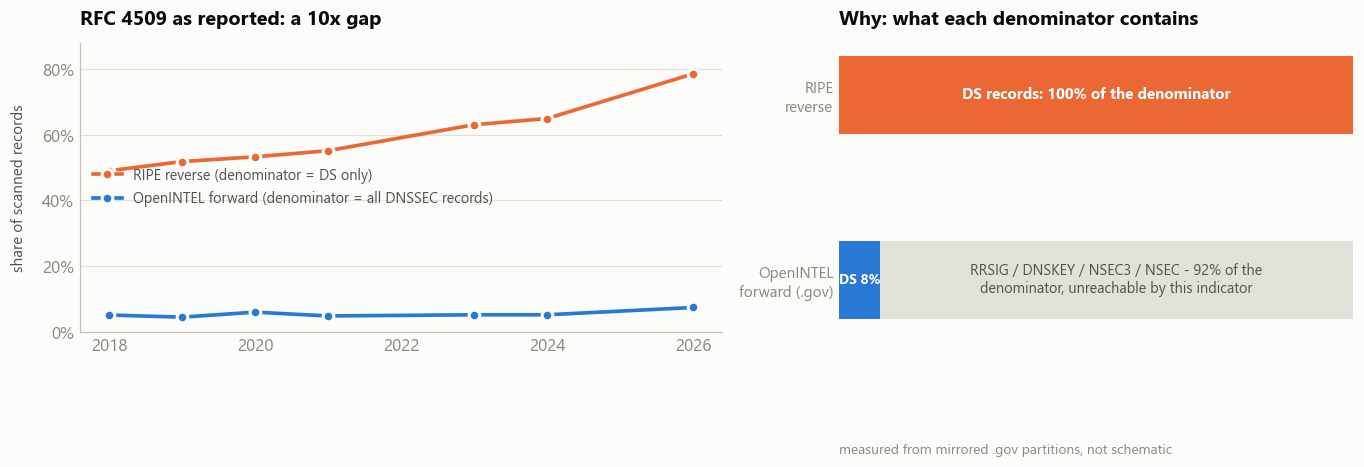

apparent gap in 2026: 10.7x

Recomputed over DS records only, which is what the reverse side measures
by construction:

                    as reported    DS-only   RIPE reverse
  forward .gov 2018        5.47%     50.09%         48.99%
  forward .gov 2026        5.09%     63.49%         78.54%

In 2018 the normalised figures agree to 1.1 percentage points.
The 10x gap was ~9x denominator. What remains in 2026 is a real difference
between the two populations, not an artefact.


In [5]:
d_fwd, d_rev = by_year(fwd, "RFC 4509"), by_year(rev, "RFC 4509")
common = sorted(set(d_fwd.index) & set(d_rev.index))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8),
                               gridspec_kw={"width_ratios": [1.25, 1]})

x = [int(y) for y in common]
ax1.plot(x, d_rev[common].values, color=REV, lw=2.4, marker="o", ms=7,
         mfc=REV, mec=SURFACE, mew=2, label="RIPE reverse (denominator = DS only)")
ax1.plot(x, d_fwd[common].values, color=FWD, lw=2.4, marker="o", ms=7,
         mfc=FWD, mec=SURFACE, mew=2, label="OpenINTEL forward (denominator = all DNSSEC records)")
style(ax1); pct(ax1); years(ax1, x)
ax1.set_ylim(0, 88)
ax1.set_title("RFC 4509 as reported: a 10x gap", color=INK, fontweight="bold",
              loc="left", pad=12)
ax1.set_ylabel("share of scanned records", color=INK_2, labelpad=10)
ax1.legend(frameon=False, fontsize=9.5, labelcolor=INK_2, loc="center left")

# The mechanism, measured. The aggregates carry no rr_type breakdown, so this is
# computed from locally mirrored .gov Parquet and cached in crossref_rrtype.json.
comp = json.loads((ROOT / "out/analysis/crossref_rrtype.json").read_text())
recent = comp["gov 2026-08"]
dist = recent["rr_type_distribution"]
total = sum(dist.values())
ds_share = (dist.get("DS", 0) + dist.get("CDS", 0)) / total * 100

ax2.barh([1], [100], color=REV, height=0.42, zorder=3)
ax2.barh([0], [100], color=GRID, height=0.42, zorder=2)
ax2.barh([0], [ds_share], color=FWD, height=0.42, zorder=3)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["OpenINTEL" + chr(10) + "forward (.gov)",
                     "RIPE" + chr(10) + "reverse"], fontsize=10)
ax2.annotate("DS records: 100% of the denominator", (50, 1), ha="center", va="center",
             color="white", fontsize=10, fontweight="bold", zorder=4)
ax2.annotate(f"DS {ds_share:.0f}%", (ds_share / 2, 0), ha="center", va="center",
             color="white", fontsize=9, fontweight="bold", zorder=4)
ax2.annotate(f"RRSIG / DNSKEY / NSEC3 / NSEC - {100 - ds_share:.0f}% of the"
             + chr(10) + "denominator, unreachable by this indicator",
             ((100 + ds_share) / 2, 0), ha="center", va="center",
             color=INK_2, fontsize=9.5, zorder=4)
style(ax2, axis="x")
ax2.set_xlim(0, 100); ax2.set_xticks([])
for side in ("left", "bottom"):
    ax2.spines[side].set_visible(False)
ax2.set_title("Why: what each denominator contains", color=INK,
              fontweight="bold", loc="left", pad=12)
ax2.annotate("measured from mirrored .gov partitions, not schematic",
             (0, -0.42), xycoords="axes fraction", color=MUTED, fontsize=9)
fig.tight_layout()
save(fig, "02_denominator_artefact"); plt.show()

print(f"apparent gap in {common[-1]}: {d_rev[common[-1]] / d_fwd[common[-1]]:.1f}x")
print()
print("Recomputed over DS records only, which is what the reverse side measures")
print("by construction:")
print()
print(f"  {'':16} {'as reported':>12} {'DS-only':>10} {'RIPE reverse':>14}")
for year, key in (("2018", "gov 2018-01-01"), ("2026", "gov 2026-08")):
    c = comp[key]
    print(f"  {'forward .gov ' + year:16} {c['rfc4509_over_all_dnssec']:11.2f}% "
          f"{c['rfc4509_over_ds_only']:9.2f}% {d_rev[year]:13.2f}%")
gap18 = abs(comp["gov 2018-01-01"]["rfc4509_over_ds_only"] - d_rev["2018"])
print()
print(f"In 2018 the normalised figures agree to {gap18:.1f} percentage points.")
print("The 10x gap was ~9x denominator. What remains in 2026 is a real difference")
print("between the two populations, not an artefact.")

## 5. What only the reverse corpus can give

### 5a. A denominator made of zones, not records

Every delegation appears in a reverse zone file, whether it is signed or not. That
makes "what fraction of **zones** are signed" directly countable — the question
the forward corpus cannot answer, and the reason its slides have to keep saying
*record-level, not zone-level*.

Two composition breaks are load-bearing, and the second one is easy to miss:

- **APNIC stops contributing in January 2025**, taking ~530,000 delegations out of
  the denominator in a single step.
- **RIPE changes publication format in October 2015**, from bulk `legacy/` zone
  files to `1.0/` inter-RIR zonelets, and its delegation count falls **97.4%**
  (695,476 → 17,836) without ever hitting zero. A panel rule that only drops RIRs
  reporting *nothing* keeps this one, and inherits the step.

So the rule used here is stricter: a RIR joins the panel only if it reports on
every measured day **and** never steps by more than 25% between consecutive
measurements. That leaves AFRINIC and ARIN — 89% of the 2026 delegations, and no
discontinuity.

Because the level depends on which panel you pick, the cell below reports all
three rather than choosing one.

largest single-step change in delegations, per RIR:
  afrinic    14.0%
  apnic     100.0%   <- excluded from the strict panel
  arin        2.9%
  lacnic     40.4%   <- excluded from the strict panel
  ripe       97.4%   <- excluded from the strict panel


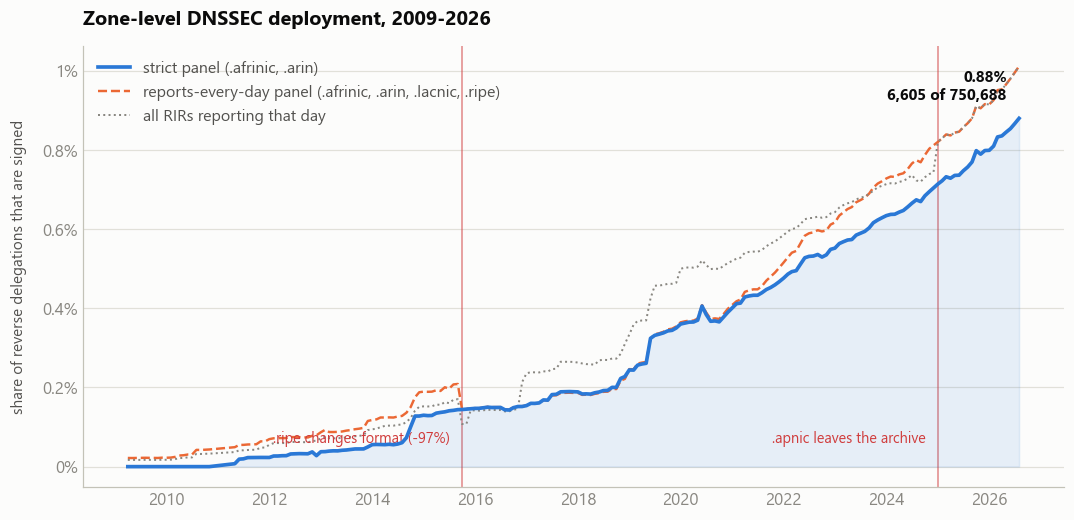


Zone-level signed share on 2026-08-01, by panel:
  strict (no step > 25%)   0.880%   crosses 1%: not yet      750,688 delegations
  reports every day        1.012%   crosses 1%: 2026-08-01   839,524 delegations
  all RIRs that day        1.012%   crosses 1%: 2026-08-01   

The level is panel-dependent (0.88-1.01%); the trend is not.
Reporting a single number without the panel would be over-claiming.


In [6]:
summaries = sorted((json.loads(p.read_text(encoding="utf-8"))
                    for p in SUMMARY_DIR.glob("*.json")), key=lambda s: s["date"])
RIRS = ("afrinic", "apnic", "arin", "lacnic", "ripe")

def n(day, rir, key):
    return int(day["per_rir"].get(rir, {}).get(key, 0))

# Largest single-step change in each RIR's delegation count. A step this size is a
# change in what the archive publishes, not in what operators deployed.
def worst_step(rir):
    vals = [n(d, rir, "delegations") for d in summaries]
    return max((abs(b - a) / a for a, b in zip(vals, vals[1:]) if a), default=0.0)

STEP_LIMIT = 0.25
steps = {r: worst_step(r) for r in RIRS}
REPORTS_ALWAYS = tuple(r for r in RIRS if all(n(d, r, "delegations") > 0 for d in summaries))
STABLE = tuple(r for r in REPORTS_ALWAYS if steps[r] <= STEP_LIMIT)
DROPPED = tuple(r for r in RIRS if r not in STABLE)
dates = [datetime.date.fromisoformat(s["date"]) for s in summaries]

print("largest single-step change in delegations, per RIR:")
for r in RIRS:
    flag = "" if r in STABLE else "   <- excluded from the strict panel"
    print(f"  {r:8} {steps[r] * 100:6.1f}%{flag}")

def series(rirs):
    sig = [sum(n(d, r, "signed_delegations") for r in rirs) for d in summaries]
    tot = [sum(n(d, r, "delegations") for r in rirs) for d in summaries]
    return [s / t * 100 if t else None for s, t in zip(sig, tot)], sig, tot

share_stable, sig_stable, tot_stable = series(STABLE)
share_all, _, _ = series(RIRS)
share_nonzero, _, tot_nonzero = series(REPORTS_ALWAYS)

fig, ax = plt.subplots(figsize=(11.5, 5.2))
ax.plot(dates, share_stable, color=FWD, lw=2.4, zorder=4,
        label=f"strict panel ({', '.join('.' + r for r in STABLE)})")
ax.fill_between(dates, share_stable, color=FWD, alpha=0.10, zorder=2)
ax.plot(dates, share_nonzero, color=REV, lw=1.6, ls="--", zorder=3,
        label=f"reports-every-day panel ({', '.join('.' + r for r in REPORTS_ALWAYS)})")
ax.plot(dates, share_all, color=MUTED, lw=1.3, ls=":", zorder=3,
        label="all RIRs reporting that day")

for rir, when, note in ((".ripe", "2015-10-01", ".ripe changes format (-97%)"),
                        (".apnic", "2025-01-01", ".apnic leaves the archive")):
    d = datetime.date.fromisoformat(when)
    ax.axvline(d, color=CRITICAL, lw=1.1, alpha=0.55, zorder=1)
    ax.annotate(note, (d, 0.06), xytext=(-8, 0), textcoords="offset points",
                ha="right", color=CRITICAL, fontsize=9.5)

style(ax); pct(ax)
ax.set_ylabel("share of reverse delegations that are signed", color=INK_2, labelpad=10)
ax.set_title("Zone-level DNSSEC deployment, 2009-2026", color=INK,
             fontweight="bold", loc="left", pad=14)
ax.annotate(f"{share_stable[-1]:.2f}%\n{sig_stable[-1]:,} of {tot_stable[-1]:,}",
            (dates[-1], share_stable[-1]), xytext=(-8, 12),
            textcoords="offset points", ha="right", color=INK, fontweight="bold")
ax.legend(frameon=False, fontsize=10.5, labelcolor=INK_2, loc="upper left")
save(fig, "03_zone_level_share"); plt.show()

print()
print(f"Zone-level signed share on {summaries[-1]['date']}, by panel:")
for label, values, totals in (("strict (no step > 25%)", share_stable, tot_stable),
                              ("reports every day", share_nonzero, tot_nonzero),
                              ("all RIRs that day", share_all, None)):
    crossed = next((d for d, v in zip(dates, values) if v and v >= 1.0), None)
    tot = f"{totals[-1]:,} delegations" if totals else ""
    print(f"  {label:24} {values[-1]:5.3f}%   crosses 1%: "
          f"{str(crossed) if crossed else 'not yet':12} {tot}")
print()
print("The level is panel-dependent (0.88-1.01%); the trend is not.")
print("Reporting a single number without the panel would be over-claiming.")

Under 1.1% of reverse delegations are signed after seventeen years. Set against
the forward corpus — where a majority of *records* in a signed zone use modern
algorithms — this is the gap between "DNSSEC is modernising where it is deployed"
and "DNSSEC is deployed".

### 5b. Adoption lag that is measured rather than bounded

The forward corpus begins in 2018-01. Any RFC published before that is
**left-censored**: the mechanism is already present on the first day we can see,
so all we can say is *"the lag was at most N years"*. Five of the eight shared
RFCs are in that state.

The reverse corpus begins in 2009-04, which is before four of the algorithm RFCs
were published. For those, the lag is a measurement.

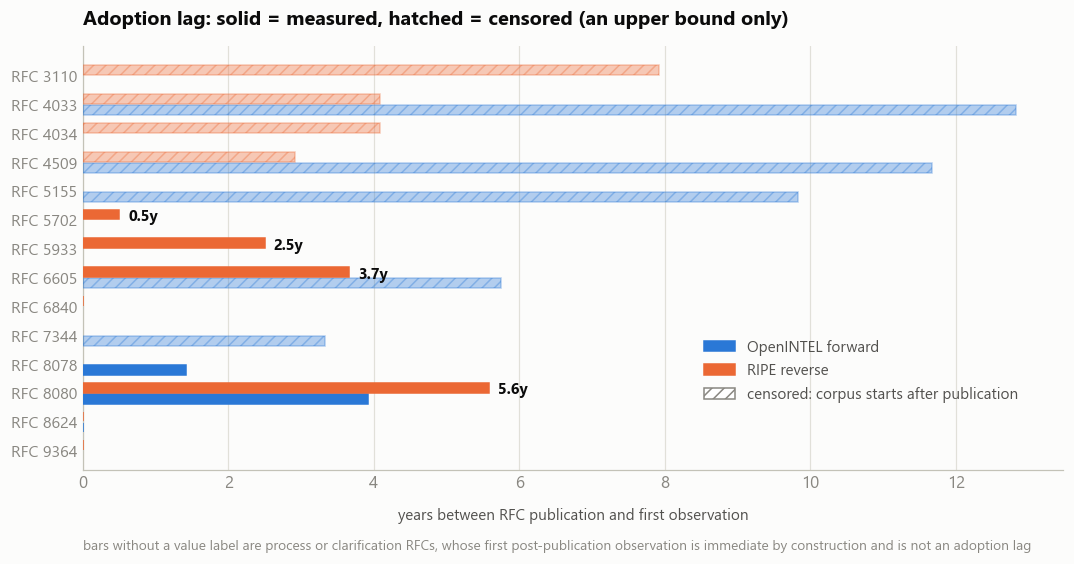

Uncensored first observations in the reverse corpus:

  RFC 5702  RSA/SHA-2  published 2009-10   lag 0.5 years
  RFC 5933  GOST       published 2010-07   lag 2.5 years
  RFC 6605  ECDSA      published 2012-04   lag 3.7 years
  RFC 6840  (process)  published 2013-02   lag 0.0 years  <- immediate by construction, not an adoption lag
  RFC 8080  EdDSA      published 2017-02   lag 5.6 years
  RFC 8624  (process)  published 2019-06   lag 0.0 years  <- immediate by construction, not an adoption lag
  RFC 9364  (process)  published 2023-02   lag 0.0 years  <- immediate by construction, not an adoption lag

The four genuine algorithm-adoption lags, in publication order:
  RFC 5702  RSA/SHA-2  0.5 years
  RFC 5933  GOST       2.5 years
  RFC 6605  ECDSA      3.7 years
  RFC 8080  EdDSA      5.6 years


In [7]:
CHECKLIST = {r["rfc_id"]: r for r in new["rfcs"]}
CORPUS_START = {"openintel": "2018-01", "reverse": summaries[0]["date"][:7]}

def months(a, b):
    return (int(b[:4]) - int(a[:4])) * 12 + (int(b[5:7]) - int(a[5:7]))

rows = []
for rfc in sorted(set(DATA["openintel"]["first_seen"]) | set(DATA["reverse"]["first_seen"]),
                  key=lambda r: int(r.split()[1])):
    published = CHECKLIST[rfc]["publication_date"][:7]
    entry = {"rfc": rfc, "published": published}
    for side in ("openintel", "reverse"):
        seen = DATA[side]["first_seen"].get(rfc)
        if seen is None:
            entry[side] = None; entry[side + "_censored"] = None
            continue
        entry[side] = months(published, seen) / 12
        entry[side + "_censored"] = seen <= CORPUS_START[side]
    rows.append(entry)

lags = pd.DataFrame(rows)
measured = lags[(lags.reverse_censored == False) & lags.reverse.notna()].copy()

fig, ax = plt.subplots(figsize=(11.5, 5.0))
y = range(len(lags))
for i, r in lags.iterrows():
    if pd.notna(r.openintel):
        censored = r.openintel_censored
        ax.barh(i + 0.19, r.openintel, height=0.34, color=FWD,
                alpha=0.35 if censored else 1.0, zorder=3,
                hatch="///" if censored else None, edgecolor=FWD)
    if pd.notna(r["reverse"]):
        censored = r.reverse_censored
        ax.barh(i - 0.19, r["reverse"], height=0.34, color=REV,
                alpha=0.35 if censored else 1.0, zorder=3,
                hatch="///" if censored else None, edgecolor=REV)
        # Label only genuine adoption lags. A `meta`/ambiguous RFC matches records
        # that already existed, so its "0.0y" is immediate by construction and
        # labelling it invites reading it as instant adoption.
        genuine = (not censored
                   and CHECKLIST[r.rfc].get("signal_type") == "adoption"
                   and r["reverse"] > 0)
        if genuine:
            ax.annotate(f"{r['reverse']:.1f}y", (r["reverse"], i - 0.19),
                        xytext=(6, -4), textcoords="offset points",
                        color=INK, fontsize=10, fontweight="bold")

style(ax, axis="x")
ax.set_yticks(list(y)); ax.set_yticklabels(lags.rfc, fontsize=10.5)
ax.invert_yaxis()
ax.set_xlabel("years between RFC publication and first observation", color=INK_2, labelpad=10)
ax.set_title("Adoption lag: solid = measured, hatched = censored (an upper bound only)",
             color=INK, fontweight="bold", loc="left", pad=14)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=FWD, label="OpenINTEL forward"),
                   Patch(color=REV, label="RIPE reverse"),
                   Patch(facecolor="white", edgecolor=MUTED, hatch="///",
                         label="censored: corpus starts after publication")],
          frameon=False, fontsize=10, labelcolor=INK_2,
          loc="upper left", bbox_to_anchor=(0.62, 0.34))
ax.annotate("bars without a value label are process or clarification RFCs, whose "
            "first post-publication observation is immediate by construction "
            "and is not an adoption lag",
            (0, -0.19), xycoords="axes fraction", color=MUTED, fontsize=9)
save(fig, "04_adoption_lag"); plt.show()

ALGOS = {"RFC 5702": "RSA/SHA-2", "RFC 5933": "GOST",
         "RFC 6605": "ECDSA", "RFC 8080": "EdDSA"}

print("Uncensored first observations in the reverse corpus:\n")
for _, r in measured.sort_values("published").iterrows():
    tag = ALGOS.get(r.rfc, "")
    if tag:
        print(f"  {r.rfc:9} {tag:10} published {r.published}   lag {r['reverse']:.1f} years")
    else:
        print(f"  {r.rfc:9} {'(process)':10} published {r.published}   "
              f"lag {r['reverse']:.1f} years  <- immediate by construction, "
              f"not an adoption lag")

print("\nThe four genuine algorithm-adoption lags, in publication order:")
for rfc, name in ALGOS.items():
    row = measured[measured.rfc == rfc]
    if not row.empty:
        print(f"  {rfc:9} {name:10} {row.iloc[0]['reverse']:.1f} years")

Ordered by publication date, the measured lags are monotonically increasing:

| RFC | Algorithm | Published | Lag |
|---|---|---|---|
| RFC 5702 | RSA/SHA-2 | 2009-10 | **0.5 y** |
| RFC 5933 | GOST | 2010-07 | **2.5 y** |
| RFC 6605 | ECDSA | 2012-04 | **3.7 y** |
| RFC 8080 | EdDSA | 2017-02 | **5.6 y** |

Each new signing algorithm took longer to appear than the one before it. Two
readings are available and this data does not choose between them: either the
ecosystem has slowed, or RSA/SHA-2 was unusually fast because it was a
drop-in change to an algorithm operators already ran, where ECDSA and EdDSA each
required new tooling and new parent support. The second is more plausible, but it
is an interpretation, not a measurement.

### 5c. Seventeen years of algorithm mix

Only the reverse corpus reaches back far enough to show the whole SHA-1 →
SHA-2 → elliptic-curve transition.

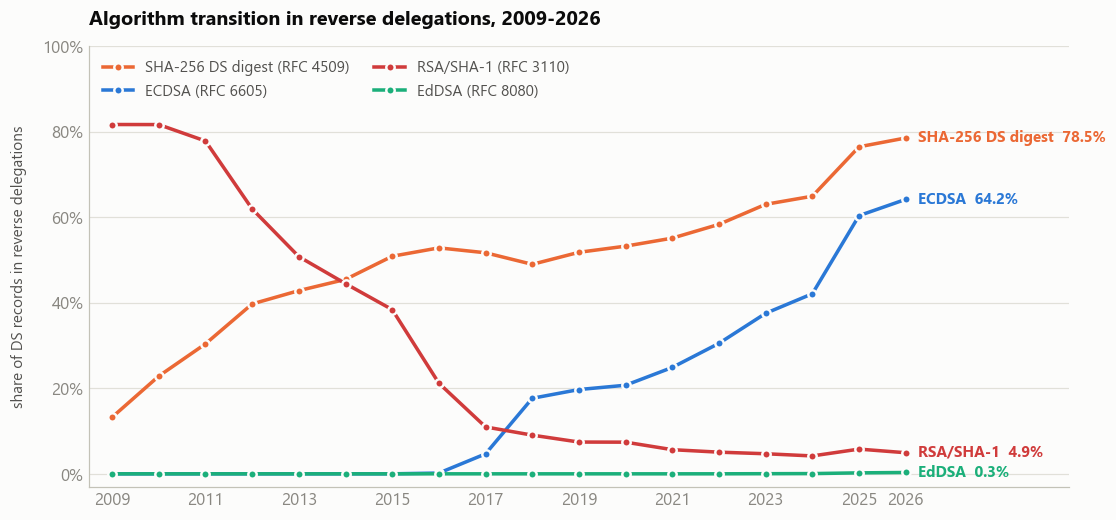

RSA/SHA-1 (deprecated by RFC 9905 in Nov 2025): 81.7% in 2009 -> 4.9% in 2026
Still non-zero, which is what RFC 9905 non-conformance will measure.


In [8]:
fig, ax = plt.subplots(figsize=(11.5, 5.2))
# Palette validated all-pairs in light mode: worst adjacent CVD dE 9.2 (deutan).
# The aqua sits below 3:1 contrast on this surface, so every series carries a
# direct end label as the required relief rather than relying on the legend.
SERIES = (("RFC 4509", "SHA-256 DS digest", "#eb6834"),
          ("RFC 6605", "ECDSA",             "#2a78d6"),
          ("RFC 3110", "RSA/SHA-1",         "#d03b3b"),
          ("RFC 8080", "EdDSA",             "#1baf7a"))

for rfc, label, colour in SERIES:
    s = by_year(rev, rfc)
    if s.empty:
        continue
    xs = [int(y) for y in s.index]
    ax.plot(xs, s.values, lw=2.3, color=colour, marker="o", ms=5.5,
            mfc=colour, mec=SURFACE, mew=1.6, label=f"{label} ({rfc})", zorder=3)
    ax.annotate(f"{label}  {s.iloc[-1]:.1f}%", (xs[-1], s.iloc[-1]),
                xytext=(8, 0), textcoords="offset points", va="center",
                color=colour, fontsize=10, fontweight="bold")

style(ax); pct(ax); years(ax, [int(y) for y in by_year(rev, "RFC 4509").index])
ax.set_ylabel("share of DS records in reverse delegations", color=INK_2, labelpad=10)
ax.set_title("Algorithm transition in reverse delegations, 2009-2026",
             color=INK, fontweight="bold", loc="left", pad=14)
ax.set_xlim(2008.5, 2029.5)          # room for the direct labels
ax.set_ylim(-3, 100)                 # headroom so the legend clears every series
ax.legend(frameon=False, fontsize=10, labelcolor=INK_2, loc="upper left",
          ncol=2, columnspacing=1.6)
save(fig, "05_algorithm_mix"); plt.show()

sha1 = by_year(rev, "RFC 3110")
print(f"RSA/SHA-1 (deprecated by RFC 9905 in Nov 2025): "
      f"{sha1.iloc[0]:.1f}% in {sha1.index[0]} -> {sha1.iloc[-1]:.1f}% in {sha1.index[-1]}")
print("Still non-zero, which is what RFC 9905 non-conformance will measure.")

## 6. Who is actually signing: address family and region

The pooled numbers hide two large structural differences. Both are computed from
the corpus directly; the queries live in `notebooks/build_crossref_notebook.py`
and their results are cached in `out/analysis/crossref_*.json`.

### 6a. IPv6 reverse delegations are an order of magnitude more likely to be signed

This is the sharpest split in the data.

panel: afrinic, arin  (199 measured days)


C:\Users\ronelgazar\AppData\Local\Temp\ipykernel_72564\3022665513.py:22: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  ax.set_xlim(fam.date.min(), fam.date.max() + pd.Timedelta(days=1500))


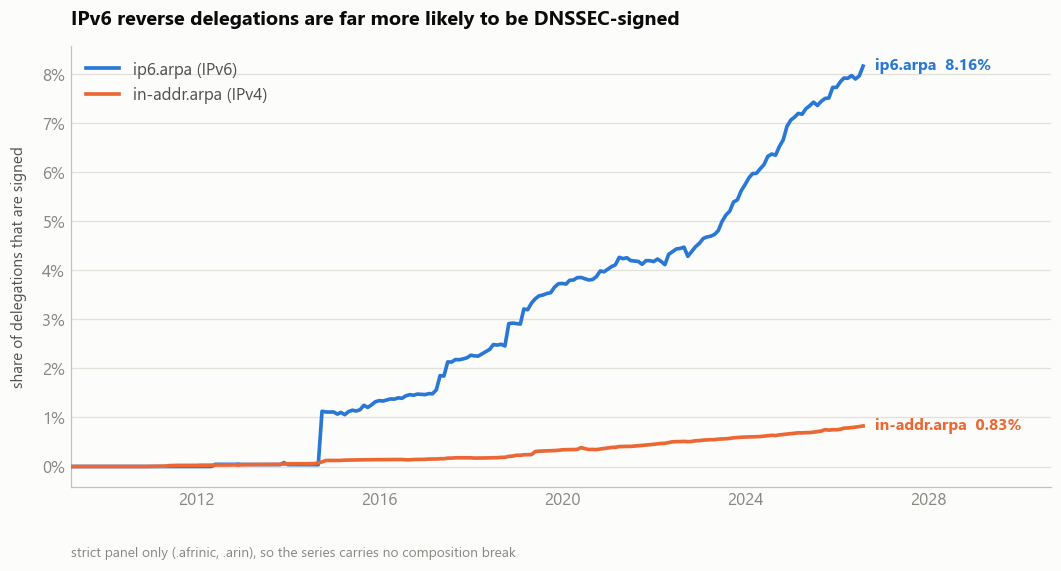

2026-08-01:
  ip6.arpa         454 of    5,567  = 8.155%
  in-addr.arpa   6,151 of  745,121  = 0.826%

  IPv6 delegations are 9.9x more likely to be signed,
  yet are only 0.7% of all reverse delegations.


In [9]:
# Per day, per RIR, per address family -- so the same strict panel from section 5a
# can be applied. Without that, APNIC's 2025 departure puts a 3-point vertical jump
# in the IPv6 series that has nothing to do with anyone signing anything.
raw = pd.DataFrame(json.loads((ROOT / "out/analysis/crossref_family_rir.json").read_text()))
fam = (raw[raw.source.isin(STABLE)]
       .groupby(["day", "fam"], as_index=False)[["delegations", "signed"]].sum())
fam["pct"] = fam.signed / fam.delegations * 100
fam["date"] = pd.to_datetime(fam.day)
print(f"panel: {', '.join(STABLE)}  ({len(fam)//2} measured days)")

fig, ax = plt.subplots(figsize=(11.5, 5.2))
for key, label, colour in (("ip6", "ip6.arpa (IPv6)", "#2a78d6"),
                           ("ip4", "in-addr.arpa (IPv4)", "#eb6834")):
    sub = fam[fam.fam == key].sort_values("date")
    ax.plot(sub.date, sub.pct, lw=2.4, color=colour, label=label, zorder=3)
    ax.annotate(f"{label.split()[0]}  {sub.pct.iloc[-1]:.2f}%",
                (sub.date.iloc[-1], sub.pct.iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", color=colour,
                fontsize=10.5, fontweight="bold")

style(ax); pct(ax)
ax.set_xlim(fam.date.min(), fam.date.max() + pd.Timedelta(days=1500))
ax.set_ylabel("share of delegations that are signed", color=INK_2, labelpad=10)
ax.set_title("IPv6 reverse delegations are far more likely to be DNSSEC-signed",
             color=INK, fontweight="bold", loc="left", pad=14)
ax.annotate(f"strict panel only ({', '.join('.' + r for r in STABLE)}), so the "
            "series carries no composition break",
            (0, -0.16), xycoords="axes fraction", color=MUTED, fontsize=9)
ax.legend(frameon=False, fontsize=11, labelcolor=INK_2, loc="upper left")
save(fig, "06_ipv4_vs_ipv6"); plt.show()

last = fam[fam.day == fam.day.max()].set_index("fam")
ratio = last.loc["ip6", "pct"] / last.loc["ip4", "pct"]
print(f"{fam.day.max()}:")
print(f"  ip6.arpa      {last.loc['ip6','signed']:>6,} of {last.loc['ip6','delegations']:>8,}"
      f"  = {last.loc['ip6','pct']:.3f}%")
print(f"  in-addr.arpa  {last.loc['ip4','signed']:>6,} of {last.loc['ip4','delegations']:>8,}"
      f"  = {last.loc['ip4','pct']:.3f}%")
print()
print(f"  IPv6 delegations are {ratio:.1f}x more likely to be signed,")
print(f"  yet are only {last.loc['ip6','delegations'] / last.delegations.sum() * 100:.1f}%"
      f" of all reverse delegations.")

The gap is not new and it is not closing: IPv6 pulls away steadily from about 2015
onward, and the ratio on the latest measured day is 9.9x. Both series are computed
on the strict panel from section 5a, so neither carries the APNIC break — on the
full set that break alone puts a three-point vertical jump in the IPv6 line.

The natural reading is **selection, not causation**. A network that has deployed
IPv6 reverse DNS at all has already done a piece of discretionary, modern DNS
work, and the same operators are the ones who sign. IPv6 delegations are also far
newer on average, provisioned by tooling that had DNSSEC support from the start,
where IPv4 reverse zones carry decades of legacy delegation.

Two things this does **not** say.

*It is not a large share of anything.* IPv6 is 0.7% of reverse delegations, so it
contributes almost nothing to the overall figure. This is a statement about *who
signs*, not about how much of the reverse tree is signed.

*It is not a smooth population curve.* The panel holds only ~5,600 IPv6
delegations, and the 2026 figure rests on **454 signed** ones. The visible step in
October 2014 is real signing rather than a composition change — the denominator
moves smoothly from 2,724 to 2,756 while the signed count jumps from 1 to 31 — but
that is one operator signing a batch. At this population size individual operators
move the line, so the *level* is solid and the *shape* should not be
over-interpreted.

### 6b. A six-fold spread between regions

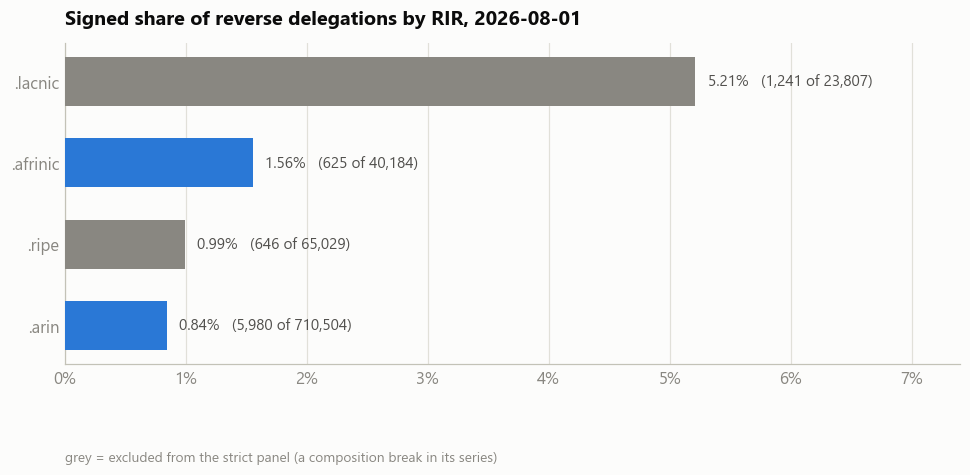

spread: 6.2x between .lacnic and .arin
but .arin holds 85% of all delegations, so it dominates every pooled figure in this notebook.


In [10]:
rir = pd.DataFrame(json.loads((ROOT / "out/analysis/crossref_rir.json").read_text()))
latest = rir[rir.day == rir.day.max()].sort_values("pct", ascending=False)

fig, ax = plt.subplots(figsize=(10.5, 3.8))
colours = ["#2a78d6" if r in STABLE else "#898781" for r in latest.source]
ax.barh(range(len(latest)), latest.pct, color=colours, height=0.6, zorder=3)
for i, (_, r) in enumerate(latest.iterrows()):
    ax.annotate(f"{r.pct:.2f}%   ({r.signed:,} of {r.deleg:,})", (r.pct, i),
                xytext=(8, 0), textcoords="offset points", va="center",
                color=INK_2, fontsize=10)
ax.set_yticks(range(len(latest)))
ax.set_yticklabels([f".{s}" for s in latest.source], fontsize=11)
ax.invert_yaxis()
style(ax, axis="x"); ax.set_xlim(0, 7.4)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}%"))
ax.set_title(f"Signed share of reverse delegations by RIR, {rir.day.max()}",
             color=INK, fontweight="bold", loc="left", pad=12)
ax.annotate("grey = excluded from the strict panel (a composition break in its series)",
            (0, -0.30), xycoords="axes fraction", color=MUTED, fontsize=9)
save(fig, "07_by_rir"); plt.show()

print(f"spread: {latest.pct.max() / latest.pct.min():.1f}x between "
      f".{latest.iloc[0].source} and .{latest.iloc[-1].source}")
print(f"but .{latest.iloc[-1].source} holds "
      f"{latest.iloc[-1].deleg / latest.deleg.sum() * 100:.0f}% of all delegations, "
      f"so it dominates every pooled figure in this notebook.")

LACNIC leads at 5.2% and ARIN trails at 0.84% — but ARIN holds 84% of the
delegations, so **the pooled number is essentially ARIN's number**. Any
"reverse DNS is N% signed" claim is really a claim about North American address
space unless it says otherwise.

Two of the four carry the composition breaks from section 5a, which is why they
are greyed: LACNIC's delegation count steps 40% in 2011 and RIPE's falls 97% in
2015. Their *levels* on the latest day are measured directly and are fine to
quote; it is their *trends* that the breaks make unreliable.

## 7. Two things the algorithm data says that adoption curves do not

### 7a. "SHA-1" means two different things, and only one is deprecated

RFC 9905 (Nov 2025) deprecates the SHA-1 **signature algorithms** — RSASHA1 (5)
and RSASHA1-NSEC3-SHA1 (7). It does *not* deprecate **DS digest type 1**, which is
also SHA-1 and which IANA still lists as RECOMMENDED for validation.

The corpus separates them and they sit at very different levels, so conflating
them would misstate the RFC 9905 exposure by about 3x.

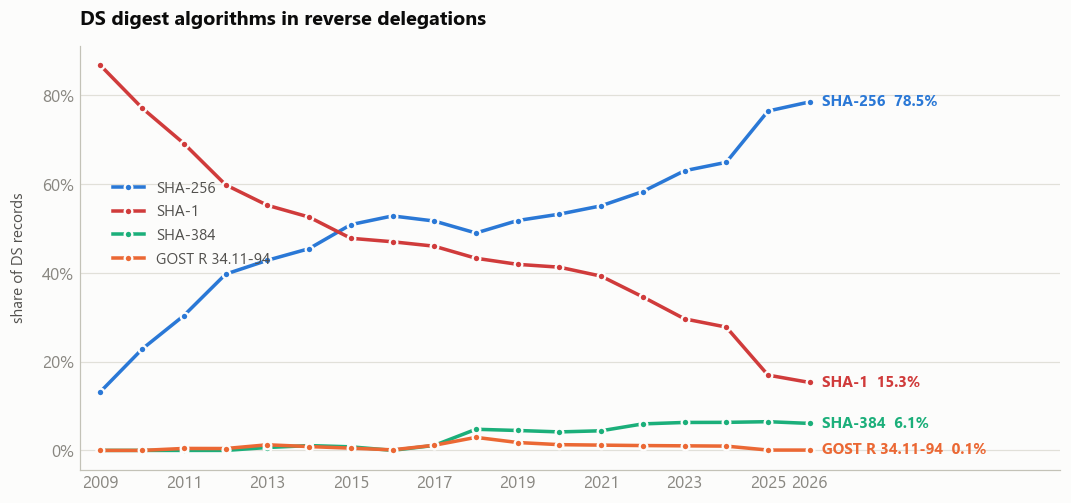

In 2026:
  SHA-1 DS *digest* (type 1)            15.3%   NOT deprecated by RFC 9905
  RSA/SHA-1 *signature* algorithm (5)    4.9%   IS deprecated by RFC 9905

  GOST R 34.11-94, retired by RFC 9906 (Nov 2025): 0.07% - already effectively gone


In [11]:
digest = pd.DataFrame(json.loads((ROOT / "out/analysis/crossref_digest.json").read_text()))
NAMES = {1: "SHA-1", 2: "SHA-256", 3: "GOST R 34.11-94", 4: "SHA-384",
         5: "GOST 2012", 6: "SM3"}
digest["name"] = digest.digest.map(NAMES).fillna(digest.digest.astype(str))
pivot = digest.pivot_table(index="yr", columns="name", values="n", aggfunc="sum").fillna(0)
pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11.5, 5.0))
cols = {"SHA-256": "#2a78d6", "SHA-1": "#d03b3b",
        "SHA-384": "#1baf7a", "GOST R 34.11-94": "#eb6834"}
for name in ("SHA-256", "SHA-1", "SHA-384", "GOST R 34.11-94"):
    if name not in pivot.columns:
        continue
    xs = [int(y) for y in pivot.index]
    ax.plot(xs, pivot[name].values, lw=2.3, color=cols[name], marker="o", ms=5,
            mfc=cols[name], mec=SURFACE, mew=1.5, label=name, zorder=3)
    ax.annotate(f"{name}  {pivot[name].iloc[-1]:.1f}%", (xs[-1], pivot[name].iloc[-1]),
                xytext=(8, 0), textcoords="offset points", va="center",
                color=cols[name], fontsize=10, fontweight="bold")
style(ax); pct(ax); years(ax, [int(y) for y in pivot.index])
ax.set_xlim(2008.5, 2032)
ax.set_ylabel("share of DS records", color=INK_2, labelpad=10)
ax.set_title("DS digest algorithms in reverse delegations", color=INK,
             fontweight="bold", loc="left", pad=14)
ax.legend(frameon=False, fontsize=10, labelcolor=INK_2, loc="center left",
          bbox_to_anchor=(0.02, 0.58))
save(fig, "08_ds_digest_types"); plt.show()

sig_sha1 = by_year(rev, "RFC 3110").iloc[-1]
dig_sha1 = pivot["SHA-1"].iloc[-1]
gost = pivot["GOST R 34.11-94"].iloc[-1] if "GOST R 34.11-94" in pivot.columns else 0.0
print(f"In {pivot.index[-1]}:")
print(f"  SHA-1 DS *digest* (type 1)           {dig_sha1:5.1f}%   NOT deprecated by RFC 9905")
print(f"  RSA/SHA-1 *signature* algorithm (5)  {sig_sha1:5.1f}%   IS deprecated by RFC 9905")
print()
print(f"  GOST R 34.11-94, retired by RFC 9906 (Nov 2025): {gost:.2f}% "
      f"- already effectively gone")

Two consequences worth carrying into the deck:

- **RFC 9905's real exposure in this corpus is ~5%, not ~15%.** The larger number
  is the DS digest, which the RFC does not touch.
- **RFC 9906 arrived after the thing it retires had already died.** GOST R
  34.11-94 is at 0.1% of DS records, down from 2.9% in 2018. The deprecation
  documents an ending rather than causing one — itself a finding about how
  algorithm retirement actually works.

### 7b. Algorithm rollovers are visible, and rare

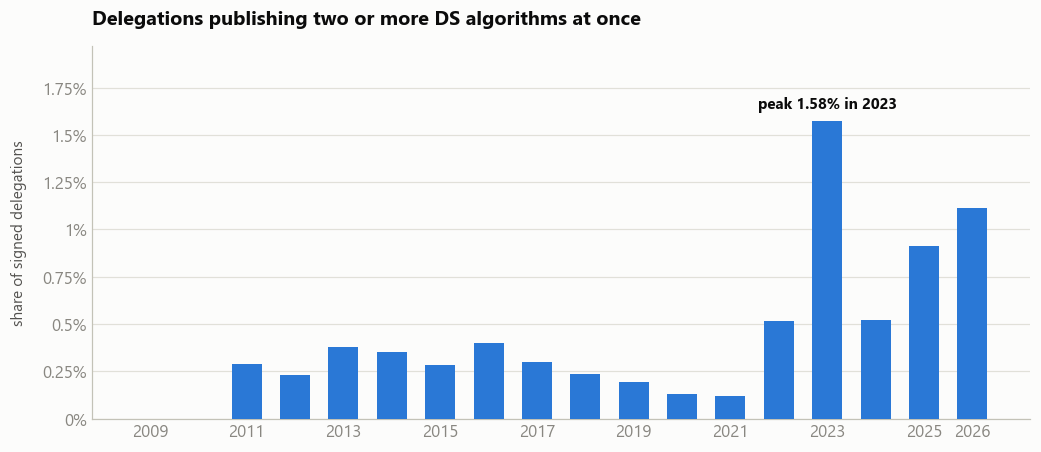

A delegation carrying 2+ distinct DS algorithms is mid-rollover: the old
algorithm is still trusted while the new one is introduced.

  2009:  0.00%  (0 of 1,258 signed delegation-days)
  2018:  0.24%  (85 of 35,819 signed delegation-days)
  2026:  1.11%  (561 of 50,364 signed delegation-days)


In [12]:
roll = pd.DataFrame(json.loads((ROOT / "out/analysis/crossref_rollover.json").read_text()))

fig, ax = plt.subplots(figsize=(11, 4.4))
xs = [int(y) for y in roll.yr]
ax.bar(xs, roll.pct, color="#2a78d6", width=0.62, zorder=3)
peak = roll.loc[roll.pct.idxmax()]
ax.annotate(f"peak {peak.pct:.2f}% in {peak.yr}", (int(peak.yr), peak.pct),
            xytext=(0, 8), textcoords="offset points", ha="center",
            color=INK, fontsize=10, fontweight="bold")
style(ax); pct(ax); years(ax, xs)
ax.set_ylim(0, peak.pct * 1.25)
ax.set_ylabel("share of signed delegations", color=INK_2, labelpad=10)
ax.set_title("Delegations publishing two or more DS algorithms at once",
             color=INK, fontweight="bold", loc="left", pad=14)
save(fig, "09_algorithm_rollover"); plt.show()

print("A delegation carrying 2+ distinct DS algorithms is mid-rollover: the old")
print("algorithm is still trusted while the new one is introduced.")
print()
for i in (0, len(roll) // 2, len(roll) - 1):
    r = roll.iloc[i]
    print(f"  {r.yr}: {r.pct:5.2f}%  ({int(r.multi):,} of {int(r.signed_days):,} "
          f"signed delegation-days)")

Around 1% of signed delegations are mid-rollover on any given day, peaking at
1.58% in 2023 — the years when ECDSA adoption was steepest (section 5c). The
signal is small, but it is the only *direct* evidence of operator activity in this
corpus: everything else measures a state, this measures a transition in progress.

It also bounds how fast the mix can move. If ~1% of delegations are rolling at any
time, an ecosystem-wide algorithm change is a decade-scale event by construction —
consistent with the 3.7-year and 5.6-year adoption lags measured in section 5b.

## 6. What this cross-reference establishes

**Corroborated across both corpora** — different infrastructure, different
operators, different collection:

1. **ECDSA is the dominant modern algorithm and both populations reached the same
   level.** ~63% of forward DNSSEC records and ~64% of reverse DS records in 2026,
   from starting points 15 points apart in 2018.
2. **EdDSA stayed marginal.** Under 1% in both, nine years after RFC 8080. The
   forward corpus alone could be dismissed as three unrepresentative zones; two
   independent corpora agreeing makes it a finding.

**Only the reverse corpus can say:**

3. **Zone-level deployment is 0.88–1.01%**, depending on which RIRs form the
   panel, after seventeen years. Whether it has "crossed 1%" is *inside* that
   uncertainty — the strict panel says no, the looser one says yes this year — so
   the threshold is not a claim worth making. The trend is robust; the level needs
   its panel stated.
4. **Measured, uncensored adoption lags**: 0.5 y (RSA/SHA-2) → 5.6 y (EdDSA),
   monotonically increasing.
5. **The SHA-1 retirement is nearly complete but not finished.** RSA/SHA-1 fell
   from 81.7% of reverse DS records in 2009 to 4.9% in 2026. RFC 9905 deprecated
   it in November 2025, so that residual 4.9% is precisely what the pipeline's
   `non_conformance` signal now measures — and the reverse corpus is the only
   place we can watch it go to zero.

**Structure the pooled numbers hide:**

6. **IPv6 reverse delegations are 9.9x more likely to be signed than IPv4 ones**
   (8.16% vs 0.83% on the strict panel), a gap that widens from 2015 onward.
   Almost certainly selection — operators who deploy IPv6 reverse DNS are the
   operators who sign — and it is the sharpest split in the data. It rests on 454
   signed delegations, so quote the ratio, not the curve's shape.
7. **A 6.2x spread between RIRs** (LACNIC 5.2%, ARIN 0.84%), and ARIN holds 85% of
   delegations. Every pooled figure here is substantially a statement about North
   American address space.
8. **"SHA-1" is two different things.** The SHA-1 *DS digest* sits at 15.3% and is
   not deprecated; the RSA/SHA-1 *signature algorithm* sits at 4.9% and is what
   RFC 9905 deprecates. Conflating them misstates the exposure by 3x.
9. **RFC 9906 retired an algorithm that was already gone** — GOST R 34.11-94 is at
   0.07% of DS records. Deprecation here documented an ending rather than causing
   one.
10. **~1% of signed delegations are mid-rollover** on any day, peaking at 1.58% in
    2023. The only direct evidence of operator *activity* in this corpus, and it
    bounds how fast the algorithm mix can move.

**A methodological result worth carrying forward:**

11. Indicators scoped by `rr_type` are **not** comparable across corpora with
   different record-type composition — RFC 4509 shows a 10x gap that is entirely
   denominator, not behaviour. Indicators scoped by *algorithm* compare cleanly.
   Any future cross-corpus claim should state which kind it is.

### Open questions

- The reverse corpus contains only `DS` and `NS` records, so RFC 5155 (NSEC3),
  7344 (CDS/CDNSKEY), 8078 and 9276 cannot be evidenced there at all. Those remain
  forward-only, and nothing here corroborates them.
- The forward side is three zones. Its agreement with the reverse corpus on ECDSA
  raises confidence, but does not make `.gov`/`.nu`/`.se` representative.
- Three of the five RIRs have a composition break in their series (APNIC leaves
  in 2025, RIPE reformats in 2015, LACNIC steps 40% in 2011). The strict panel
  handles this by dropping them, at the cost of leaning almost entirely on ARIN.
  A better treatment would splice the RIPE series across its format change rather
  than discarding it; that needs someone who knows what the `legacy/` bulk zones
  contained relative to the `1.0/` zonelets.
- The IPv6 result is a correlation with no causal test behind it. Confirming the
  selection story would mean checking whether the *same operators* run both, which
  needs delegation-to-operator attribution this corpus does not carry.

In [13]:
print("Figures written to", FIGDIR.resolve())
for p in sorted(FIGDIR.glob("*.png")):
    print(f"  {p.name:32} {p.stat().st_size / 1024:6.0f} KB")

Figures written to E:\Documents\University\year2\DNSSEC\rfc_adoption\reporting\charts\crossref
  01_ecdsa_convergence.png            122 KB
  02_denominator_artefact.png         131 KB
  03_zone_level_share.png             152 KB
  04_adoption_lag.png                 145 KB
  05_algorithm_mix.png                159 KB
  06_ipv4_vs_ipv6.png                 115 KB
  07_by_rir.png                        72 KB
  08_ds_digest_types.png              126 KB
  09_algorithm_rollover.png            62 KB
